In [1]:
import torch
import nn4n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

N, C = 512, 100
model_cfg = {
            "input_dim":    C,
            "hidden_dim":   N,
            'output_dim':   C,
            "alpha":        0.01,
            "learn_alpha":  False,
            "preact_noise": 0.1,
            "postact_noise":0.1
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


# def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
#     """
#     Args:
#         recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
#         target: [batch, time, dim] — ground truth experience vectors (y)
#         firing_rates: [batch, time, N] — firing rates of all hidden neurons
#     """

#     # Shape values
#     B, T, D = target.shape
#     N = firing_rates[0].shape[2]

#     # 1. Reconstruction MSE Loss
#     mse = torch.sum((recon - target) ** 2) / (B * T * D)
#     # mse = torch.nn.MSELoss()
#     # mse = mse(recon, target)

#     # 2. Firing rate regularization term
#     reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

#     total_loss = lambda_mse * mse + lambda_r * reg
#     # print(lambda_mse * mse, lambda_r * reg)
#     return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

Using device: cuda


In [2]:
import numpy as np
load_data_type = '2TS_1_data'

data = np.load(f'../time_exp/{load_data_type}.npy', allow_pickle=True).item()
test_inputs = data['test_inputs']
print(test_inputs.shape)

torch.Size([7, 200, 100])


In [3]:
# Load model weights 
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))

# ------------------------------ Modify the trained weights ------------------------------
# # Change the initialization of input weights
# model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(np.random.uniform(-np.sqrt(1/C), np.sqrt(1/C), size=(N, C)).astype(np.float32)).to(device)

# # Shuffle the recurrent weights
# new_order = np.random.permutation(N)
# trained_Wrc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'].cpu().numpy()
# shuffled_Wrc = trained_Wrc[new_order,:][:,new_order]
# model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(shuffled_Wrc.astype(np.float32)).to(device)
# trained_brc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.bias'].cpu().numpy()
# shuffled_brc = trained_brc[new_order]
# model_dict['recurrent_layers.0.leaky_layer.linear_layer.bias'] = torch.from_numpy(shuffled_brc.astype(np.float32)).to(device)
# # Shuffle the projection weights accordingly
# trained_Win = model_dict['recurrent_layers.0.projection_layer.weight'].cpu().numpy()
# shuffled_Win = trained_Win[new_order,:]
# model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(shuffled_Win.astype(np.float32)).to(device)
# trained_bin = model_dict['recurrent_layers.0.projection_layer.bias'].cpu().numpy()
# shuffled_bin = trained_bin[new_order]
# model_dict['recurrent_layers.0.projection_layer.bias'] = torch.from_numpy(shuffled_bin.astype(np.float32)).to(device)
# ------------------------------------------------------------------------------------------      

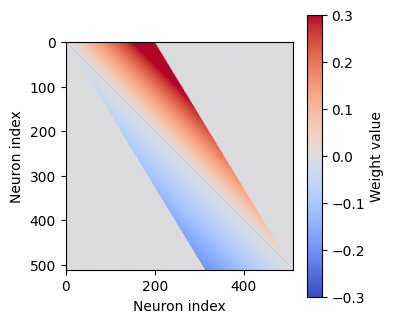

In [10]:
model_dict = torch.load(f'../time_exp/2TS_1_rnn.pth', map_location=torch.device('cuda'))

# Create a recurrent weight matrix
Wrc = np.zeros((N,N))
# Assign negative weights to all elements of Wrc
Wrc = np.random.normal(loc=-0.0025, scale=0.01, size=(N, N))
# Initiate the diagonal elements
diags = np.random.normal(loc=-0.15, scale=0.02, size=(N)) 
Delta, gain, loss = 200, 0.002, 0.001
# Set up limits for each row
limits1 = np.linspace(Delta, 0, N, dtype=int)
limits2 = np.linspace(0, Delta, N, dtype=int)
for i in range(N):
    Wrc[i,i] = diags[i]
    for j in range(N):
        if j > i and j < (i + limits1[i]):
            Wrc[i,j] = (j-i) * gain
        if j < i and j > (i - limits2[i]):
            Wrc[i,j] = (j-i) * loss

model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(Wrc.astype(np.float32)).to(device)
    
# Plot the Wrc matrix
from matplotlib import pyplot as plt
plt.figure(figsize=(4,3.5))
# Set colorbar symmetric around zero
plt.imshow(Wrc, cmap='coolwarm', vmin=-0.3, vmax=0.3)
plt.colorbar(label='Weight value')
plt.xlabel('Neuron index')
plt.ylabel('Neuron index')
plt.tight_layout()
plt.savefig('Wrc_theory.png', transparent=True, dpi=500)

np.save('Wrc_theory.npy', Wrc)

# ------------------------------ Modify the idealised weights ------------------------------
# Replace Wrc with idealised Wrc
# ideal_Wrc = np.load('Wrc_theory.npy')
# model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(ideal_Wrc.astype(np.float32)).to(device)

# # Shuffle Wrc 
# new_order = np.random.permutation(N)
# ideal_Wrc = ideal_Wrc[new_order,:][:,new_order]
# model_dict['recurrent_layers.0.leaky_layer.linear_layer.weight'] = torch.from_numpy(ideal_Wrc.astype(np.float32)).to(device)

# trained_brc = model_dict['recurrent_layers.0.leaky_layer.linear_layer.bias'].cpu().numpy()
# shuffled_brc = trained_brc[new_order]
# model_dict['recurrent_layers.0.leaky_layer.linear_layer.bias'] = torch.from_numpy(shuffled_brc.astype(np.float32)).to(device)

# # Shuffle the projection weights accordingly
# trained_Win = model_dict['recurrent_layers.0.projection_layer.weight'].cpu().numpy()
# shuffled_Win = trained_Win[new_order,:]
# model_dict['recurrent_layers.0.projection_layer.weight'] = torch.from_numpy(shuffled_Win.astype(np.float32)).to(device)

# trained_bin = model_dict['recurrent_layers.0.projection_layer.bias'].cpu().numpy()
# shuffled_bin = trained_bin[new_order]
# model_dict['recurrent_layers.0.projection_layer.bias'] = torch.from_numpy(shuffled_bin.astype(np.float32)).to(device)
# ------------------------------------------------------------------------------------------ 


In [5]:
rnn.load_state_dict(model_dict)
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)
test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
avg_fr = np.mean(hidden_states, axis=0)

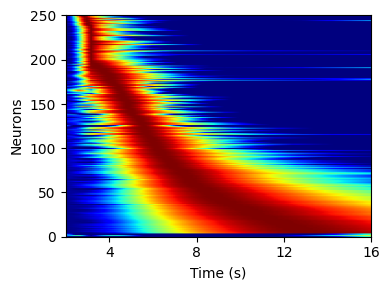

In [6]:
from matplotlib import pyplot as plt
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from func import plt_hs

fig, ax = plt.subplots(figsize=(4,3))
norm_hs, fig, ax = plt_hs(avg_fr, ax=ax, fig=fig, min_fr=0.1)
ax.set_xlabel('Time (s)')
ax.set_xlim(2,16)
plt.tight_layout()
plt.savefig(f'theory_rnn_{load_data_type}_{N}_hs.png', transparent=True)